In [ ]:
# DO THIS BEFORE RUNNING ANYTHING ELSE
# Make sure to have Jupyter Notebook Extension downloaded too
# And Python I guess if you don't have it yet
# Then Open Terminal and make sure to be in the root/main directory of this project then run these codes:
# python -m venv .venv
# .\.venv\Scripts\activate

In [1]:
# Setup

%pip install -q numpy pandas scikit-learn tensorflow transformers matplotlib seaborn kaggle

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Downloading Dataset uWu

import os
import zipfile
from pathlib import Path

dataset_dir = Path('fake-and-real-news-dataset')  
kaggle_json = Path('kaggle.json')  

if not dataset_dir.exists():
    if not kaggle_json.exists():
        raise FileNotFoundError(
            "Please download kaggle.json from your Kaggle account and "
            f"place it in your project folder at: {Path.cwd()}"
        )
    
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(exist_ok=True)
    
    import shutil
    shutil.copy(kaggle_json, kaggle_dir / 'kaggle.json')
    
    if os.name != 'nt': 
        os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    
    import subprocess
    try:
        subprocess.run([
            'kaggle', 'datasets', 'download',
            '-d', 'clmentbisaillon/fake-and-real-news-dataset'
        ], check=True)
    except FileNotFoundError:
        raise RuntimeError(
            "Kaggle CLI not installed. Run: pip install kaggle"
        )
    
    zip_path = 'fake-and-real-news-dataset.zip'
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    
    os.remove(zip_path)
    print(f"✅ Dataset downloaded to: {dataset_dir.resolve()}")
else:
    print("✅ Dataset already exists")

✅ Dataset downloaded to: C:\Users\renor\Downloads\C20FinalProject\fake-and-real-news-dataset


Matplotlib is building the font cache; this may take a moment.


Dataset size: 44147 (Fake: 23481, Real: 21417)


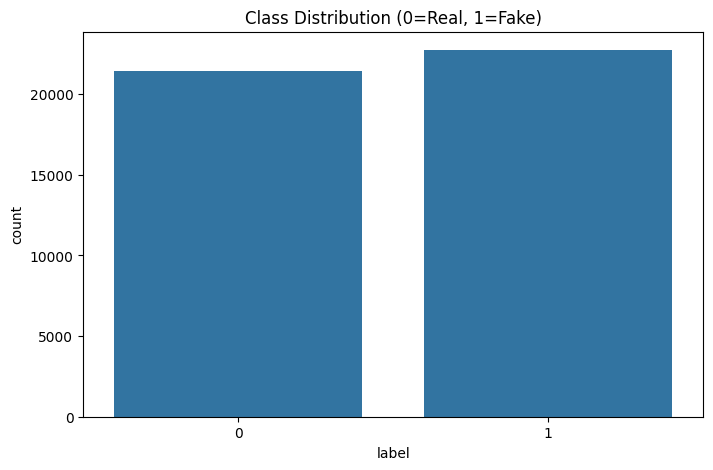

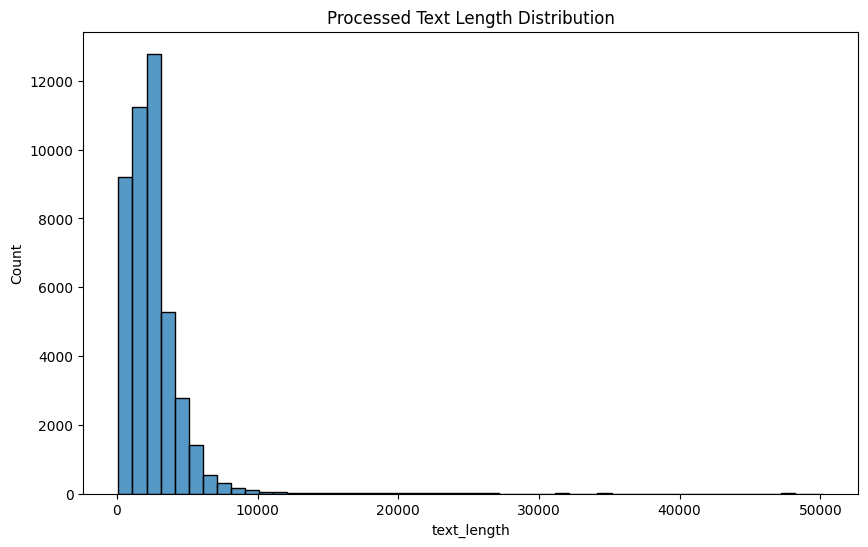

In [2]:
# Preprocessing

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = "./fake-and-real-news-dataset/"
fake_df = pd.read_csv(f'{dataset_path}Fake.csv')
true_df = pd.read_csv(f'{dataset_path}True.csv')

fake_df['label'] = 1  # 1 for fake news
true_df['label'] = 0  # 0 for real news
df = pd.concat([fake_df, true_df], axis=0)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['full_text'] = df['title'] + " " + df['text']

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)  
    text = re.sub(r'\d+', '', text)       
    text = re.sub(r'\s+', ' ', text).strip()  
    return text

df['clean_text'] = df['full_text'].apply(preprocess)
df = df[df['clean_text'].str.split().str.len() > 20].reset_index(drop=True)

X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

df['text_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['title_length'] = df['title'].apply(len)

df.to_csv('preprocessed_news.csv', index=False)
print(f"Dataset size: {len(df)} (Fake: {len(fake_df)}, Real: {len(true_df)})")

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df)
plt.title('Class Distribution (0=Real, 1=Fake)')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['text_length'], bins=50)
plt.title('Processed Text Length Distribution')
plt.show()

In [5]:
# Feature Engineering Part

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, save_npz
import numpy as np
import joblib  # For saving scalers/vectorizers

# TF-IDF for traditional models (RF, Logistic Regression)
tfidf = TfidfVectorizer(max_features=10000, stop_words='english', 
                        ngram_range=(1, 3), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

def get_metadata_features(df, indices):
    subset = df.loc[indices]
    features = np.vstack([
        np.log1p(subset['text_length']),  
        np.log1p(subset['word_count']),
        subset['title_length'] / 100,
        (subset['word_count'] / subset['text_length']) * 1000  
    ]).T
    return features

X_train_meta = get_metadata_features(df, X_train.index)
X_test_meta = get_metadata_features(df, X_test.index)

# Scale metadata features
meta_scaler = StandardScaler()
X_train_meta_scaled = meta_scaler.fit_transform(X_train_meta)
X_test_meta_scaled = meta_scaler.transform(X_test_meta)

# Save scaler for inference
joblib.dump(meta_scaler, 'meta_scaler.joblib')

# Combined features for traditional models
X_train_combined = hstack([X_train_tfidf, X_train_meta_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_meta_scaled])

print("✅ Feature engineering complete!")

✅ Feature engineering complete!


Running feature importance analysis...


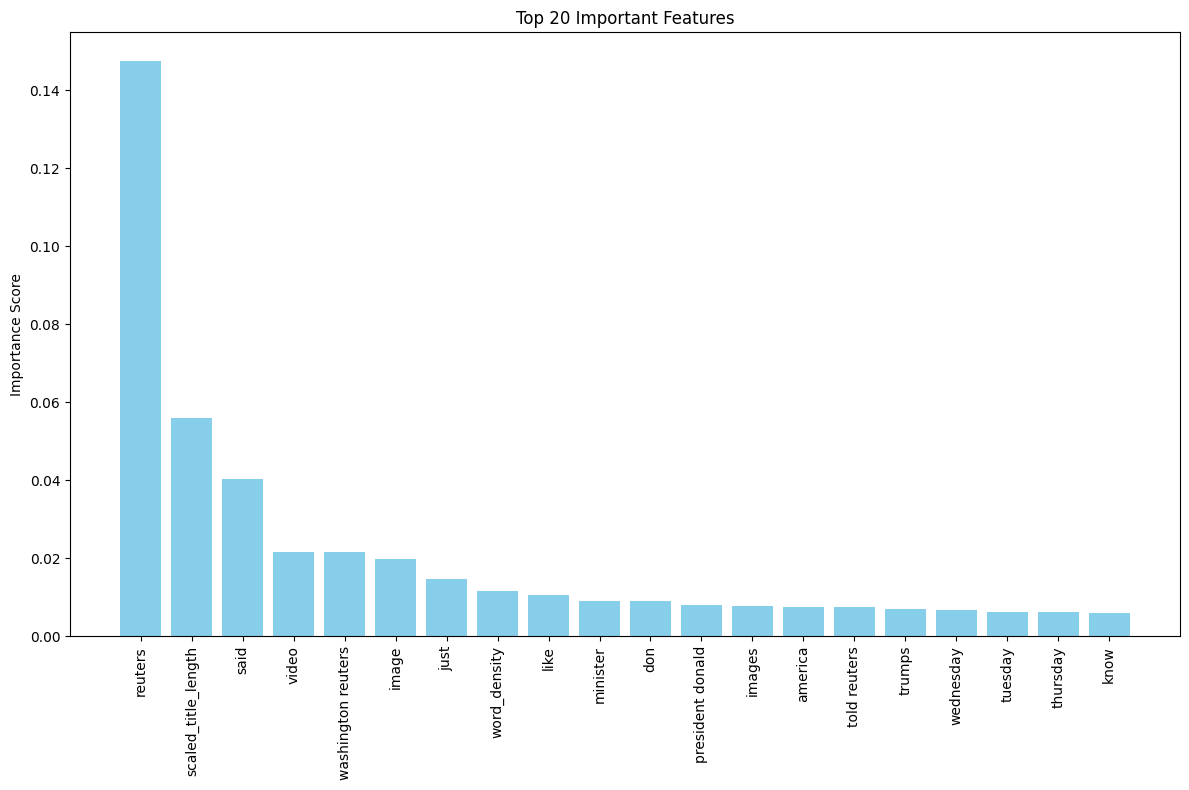


Top 20 Features:
reuters: 0.1475
scaled_title_length: 0.0561
said: 0.0402
video: 0.0217
washington reuters: 0.0216
image: 0.0197
just: 0.0145
word_density: 0.0115
like: 0.0105
minister: 0.0091
don: 0.0089
president donald: 0.0079
images: 0.0077
america: 0.0075
told reuters: 0.0074
trumps: 0.0069
wednesday: 0.0068
tuesday: 0.0062
thursday: 0.0061
know: 0.0058


In [9]:
# Feature Importance Analysis
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

print("Running feature importance analysis...")

X_train_csr = X_train_combined.tocsr()

sample_size = min(5000, X_train_csr.shape[0])

X_train_dense = X_train_csr[:sample_size].toarray()

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train_dense, y_train[:sample_size])

tfidf_feature_names = tfidf.get_feature_names_out()
meta_feature_names = ['log_text_length', 'log_word_count', 'scaled_title_length', 'word_density']
all_feature_names = np.concatenate([tfidf_feature_names, meta_feature_names])

importances = clf.feature_importances_
top_20_idx = importances.argsort()[::-1][:20]
top_20_names = [all_feature_names[i] for i in top_20_idx]
top_20_importances = importances[top_20_idx]

plt.figure(figsize=(12, 8))
plt.bar(range(20), top_20_importances, color='skyblue')
plt.xticks(range(20), top_20_names, rotation=90)
plt.title('Top 20 Important Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 20 Features:")
for name, imp in zip(top_20_names, top_20_importances):
    print(f"{name}: {imp:.4f}")


Applying dimensionality reduction...


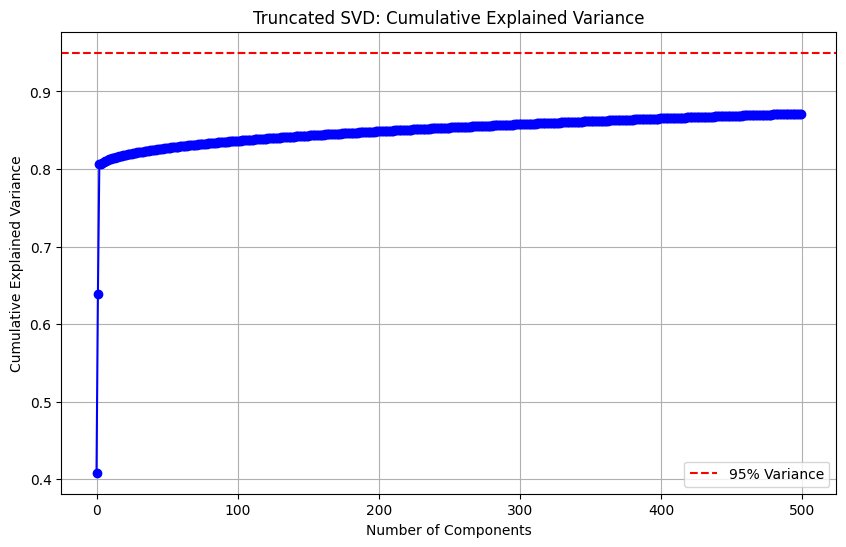

Components needed for 95% variance: 1


In [10]:
# Dimensionality Reduction (Truncated SVD)
from sklearn.decomposition import TruncatedSVD

print("Applying dimensionality reduction...")
svd = TruncatedSVD(n_components=500, random_state=42)
X_train_reduced = svd.fit_transform(X_train_combined)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(svd.explained_variance_ratio_), 'b-', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Truncated SVD: Cumulative Explained Variance')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()
plt.savefig('svd_variance.png')
plt.show()

print(f"Components needed for 95% variance: {np.argmax(np.cumsum(svd.explained_variance_ratio_) >= 0.95) + 1}")

In [11]:
# Save datasets for different model types

# For traditional models
save_npz('X_train_traditional.npz', X_train_combined)
save_npz('X_test_traditional.npz', X_test_combined)

# For deep learning models (save raw text + metadata)
np.save('X_train_text.npy', X_train.values)
np.save('X_test_text.npy', X_test.values)
np.save('X_train_meta.npy', X_train_meta)
np.save('X_test_meta.npy', X_test_meta)

# Labels
np.save('y_train.npy', y_train.values)
np.save('y_test.npy', y_test.values)

# Save full metadata for later use
df[['clean_text', 'text_length', 'word_count', 'title_length', 'label']].to_csv(
    'full_processed_data.csv', index=False
)

print("✅ Dataset saving complete!")

✅ Dataset saving complete!


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

X_train_combined = load_npz('X_train_combined.npz')
X_test_combined = load_npz('X_test_combined.npz')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')

lr = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42, class_weight='balanced')
lr.fit(X_train_combined, y_train)
lr_pred = lr.predict(X_test_combined)

print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=['Real', 'Fake']))

Logistic Regression Performance:
Accuracy: 0.9922
F1 Score: 0.9924
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4283
        Fake       1.00      0.99      0.99      4547

    accuracy                           0.99      8830
   macro avg       0.99      0.99      0.99      8830
weighted avg       0.99      0.99      0.99      8830



In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42, class_weight='balanced')
rf.fit(X_train_combined, y_train)
rf_pred = rf.predict(X_test_combined)

print("\nRandom Forest Performance:")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred, target_names=['Real', 'Fake']))


Random Forest Performance:
Accuracy: 0.9983
F1 Score: 0.9983
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4283
        Fake       1.00      1.00      1.00      4547

    accuracy                           1.00      8830
   macro avg       1.00      1.00      1.00      8830
weighted avg       1.00      1.00      1.00      8830



In [ ]:
# LSTM

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

if tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X_train)

max_len = 256
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(X_test_seq, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(
    X_train_pad, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)]
)

lstm_pred = (model.predict(X_test_pad) > 0.5).astype(int)
print("\nLSTM Performance:")
print(f"Accuracy: {accuracy_score(y_test, lstm_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lstm_pred):.4f}")
print(classification_report(y_test, lstm_pred, target_names=['Real', 'Fake']))

Epoch 1/8


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


249/249 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.8817 - loss: 0.3002 - val_accuracy: 0.9810 - val_loss: 0.0626
Epoch 2/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.9781 - loss: 0.0644 - val_accuracy: 0.9870 - val_loss: 0.0475
Epoch 3/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 324s 1s/step - accuracy: 0.9905 - loss: 0.0318 - val_accuracy: 0.9878 - val_loss: 0.0409
Epoch 4/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.9951 - loss: 0.0151 - val_accuracy: 0.9861 - val_loss: 0.0508
Epoch 5/8
249/249 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.9978 - loss: 0.0061 - val_accuracy: 0.9907 - val_loss: 0.0473
276/276 ━━━━━━━━━━━━━━━━━━━━ 32s 113ms/step

LSTM Performance:
Accuracy: 0.9849
F1 Score: 0.9855
              precision    recall  f1-score   support

        Real       0.99      0.98      0.98      4283
        Fake       0.98      0.99      0.99      4547

    accuracy                           0.98      8830
   macro avg       0.99      0.98      0.98      8830
w

In [ ]:
# DistilBERT

from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf
from transformers.optimization_tf import create_optimizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts):
    return tokenizer(
        texts.tolist(),
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors="tf"
    )

train_encodings = tokenize_texts(X_train)
test_encodings  = tokenize_texts(X_test)

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    y_train
)).shuffle(1000).batch(16)

test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    y_test
)).batch(16)

model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

num_train_steps = len(train_dataset) * 3

optimizer, lr_schedule = create_optimizer(
    init_lr=5e-5,
    num_warmup_steps=0,
    num_train_steps=num_train_steps
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=3
)

bert_pred = np.argmax(model.predict(test_dataset).logits, axis=1)

bert_pred = np.argmax(model.predict(test_dataset).logits, axis=1)
print("\nDistilBERT Performance:")
print(f"Accuracy: {accuracy_score(y_test, bert_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, bert_pred):.4f}")
print(classification_report(y_test, bert_pred, target_names=['Real', 'Fake']))

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_projector.bias', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

Epoch 1/3
 291/2208 [==>...........................] - ETA: 12:23:02 - loss: 0.0477 - accuracy: 0.9854

In [ ]:
# Results and Visualization Part

results = []
models = [
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('LSTM', lstm_pred.flatten()),
    ('DistilBERT', bert_pred)
]

for name, pred in models:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1 Score': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred)
    })

# Comparison table
results_df = pd.DataFrame(results)
print("\n=== MODEL COMPARISON ===")
print(results_df)

# Plot results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='F1 Score', data=results_df, palette='viridis')
plt.title('F1 Score Comparison')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='mako')
plt.title('Accuracy Comparison')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()

results_df.to_csv('model_results.csv', index=False)

# Confusion matrix
plt.figure(figsize=(15, 10))
for i, (name, pred) in enumerate(models, 1):
    cm = confusion_matrix(y_test, pred)
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()